### Self Attention
LSTM의 한계
- Seq2Seq의 디코더는 인코더의 "마지막 은닉상태 하나"만 보고 만든 출력 단어를 생성해야 했음

Attention의 해결책 <br>
-> "마지막 것만 보지 말고, 인코더가 만든 모든 시점의 은닉 상태를 그대로 남겨두자. 그리고 디코더가 단어를 생성할 때마다 그 순간 가장 관련 있는(내적 활용) 인코더 시점을 그 때마다 찾아 집중하자"
- 벡터를 하나의 "행렬"로 만들어 입력값으로 사용

#### 1. Q, K, V
- Query(질의): 내가 지금 찾고 싶은 것 - "이 책에 대해 알고 싶어요"
- Key(색인): 도서관의 색인 카드 - "각 책에 붙은 표식"
- Value(실제 내용): 색인을 보고 찾아간 책의 실제 내용(Key로 검색해 찾아낸, 진짜로 가져올 정보)

즉, Query로 모든 Key를 매칭 -> 가장 잘 맞는 Key에 대응하는 Value를 가져온다

Q1. 단순히 단어 임베딩을 비교하지 않고 Q, K, V로 따로 변환하는 이유
A1. 하나의 임베딩이 "Query(검색 역할)", "Key(검색당하는 역할)", "Value(실제로 전달할 내용)"을 동시에 수행하기 어렵기 때문

- 수식
$$ Attention(Q, K, V) = Softmax(\frac{QK^T}{\sqrt{d_k}}V) $$

$Q(Query) = XW_Q$ <br>
$K(Key) = XW_K$ <br>
$V(Value) = XW_V$

##### (1) $QK^T$ - 모든 단어 쌍의 유사도 계산
: Q와 K는 각각 $(문장 길이 \times d_k)$ 형태의 행렬
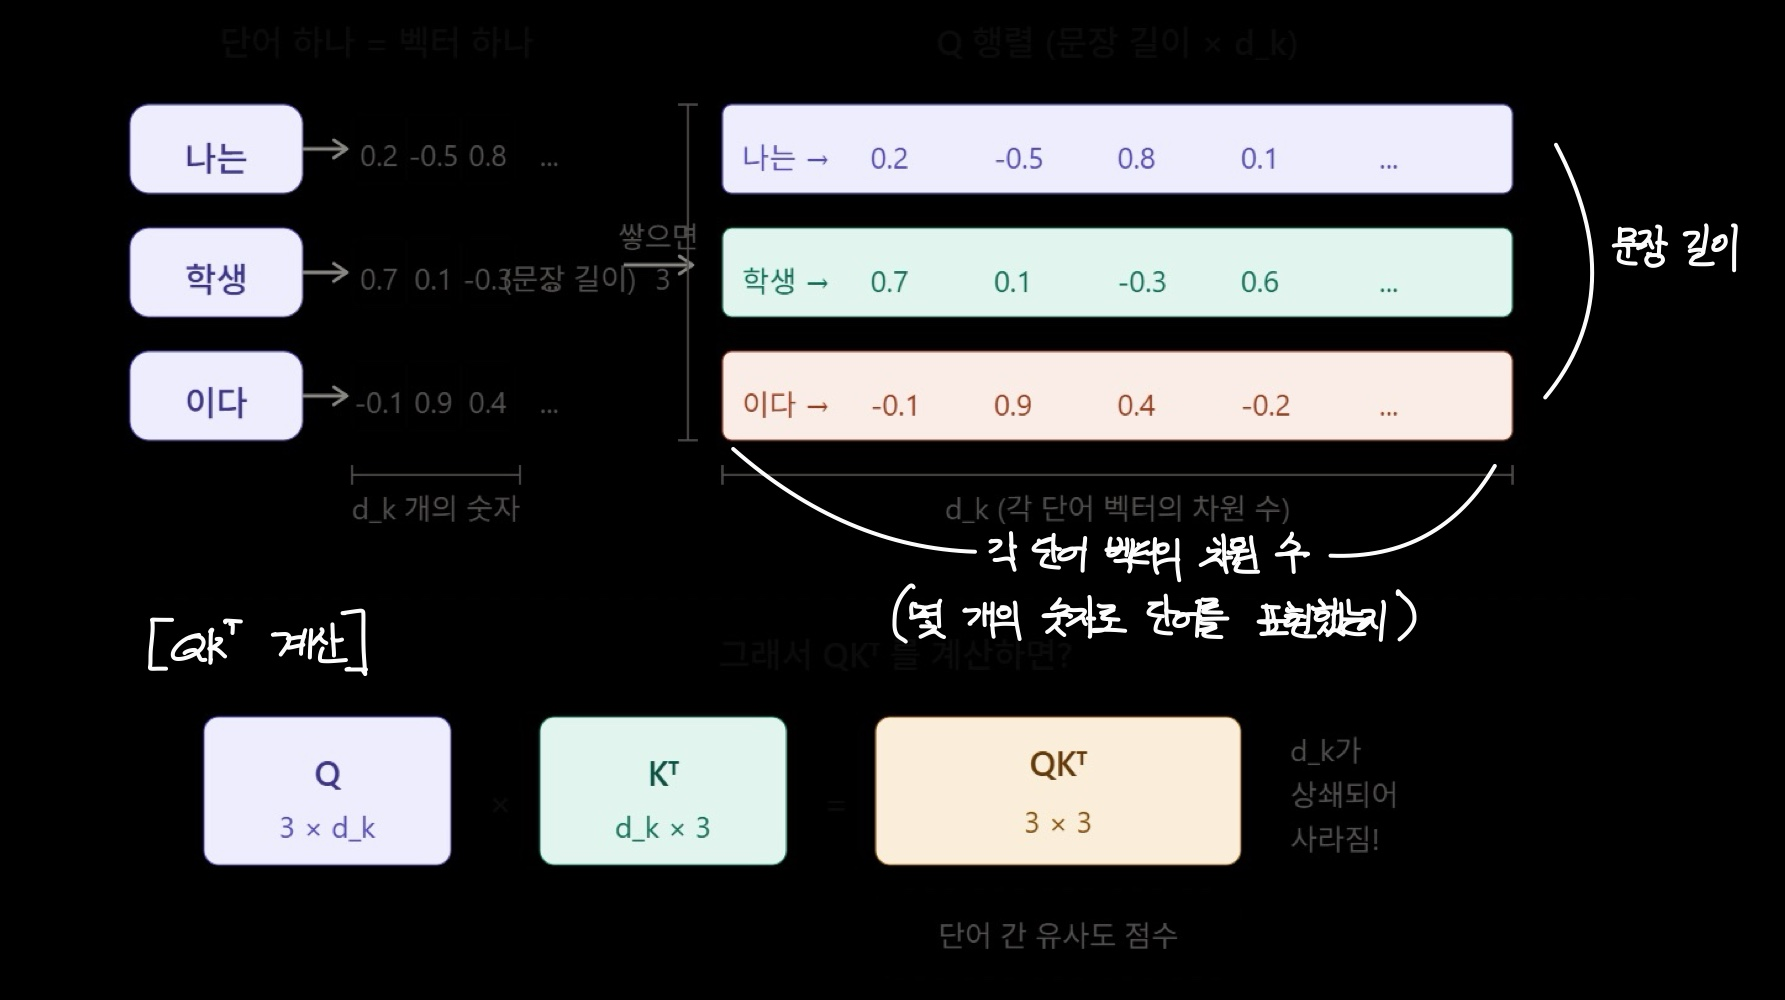
$QK^T$를 계산하면 : <br>
$QK^T \in R^{{문장 길이} \times (문장 길이)}$ <br>
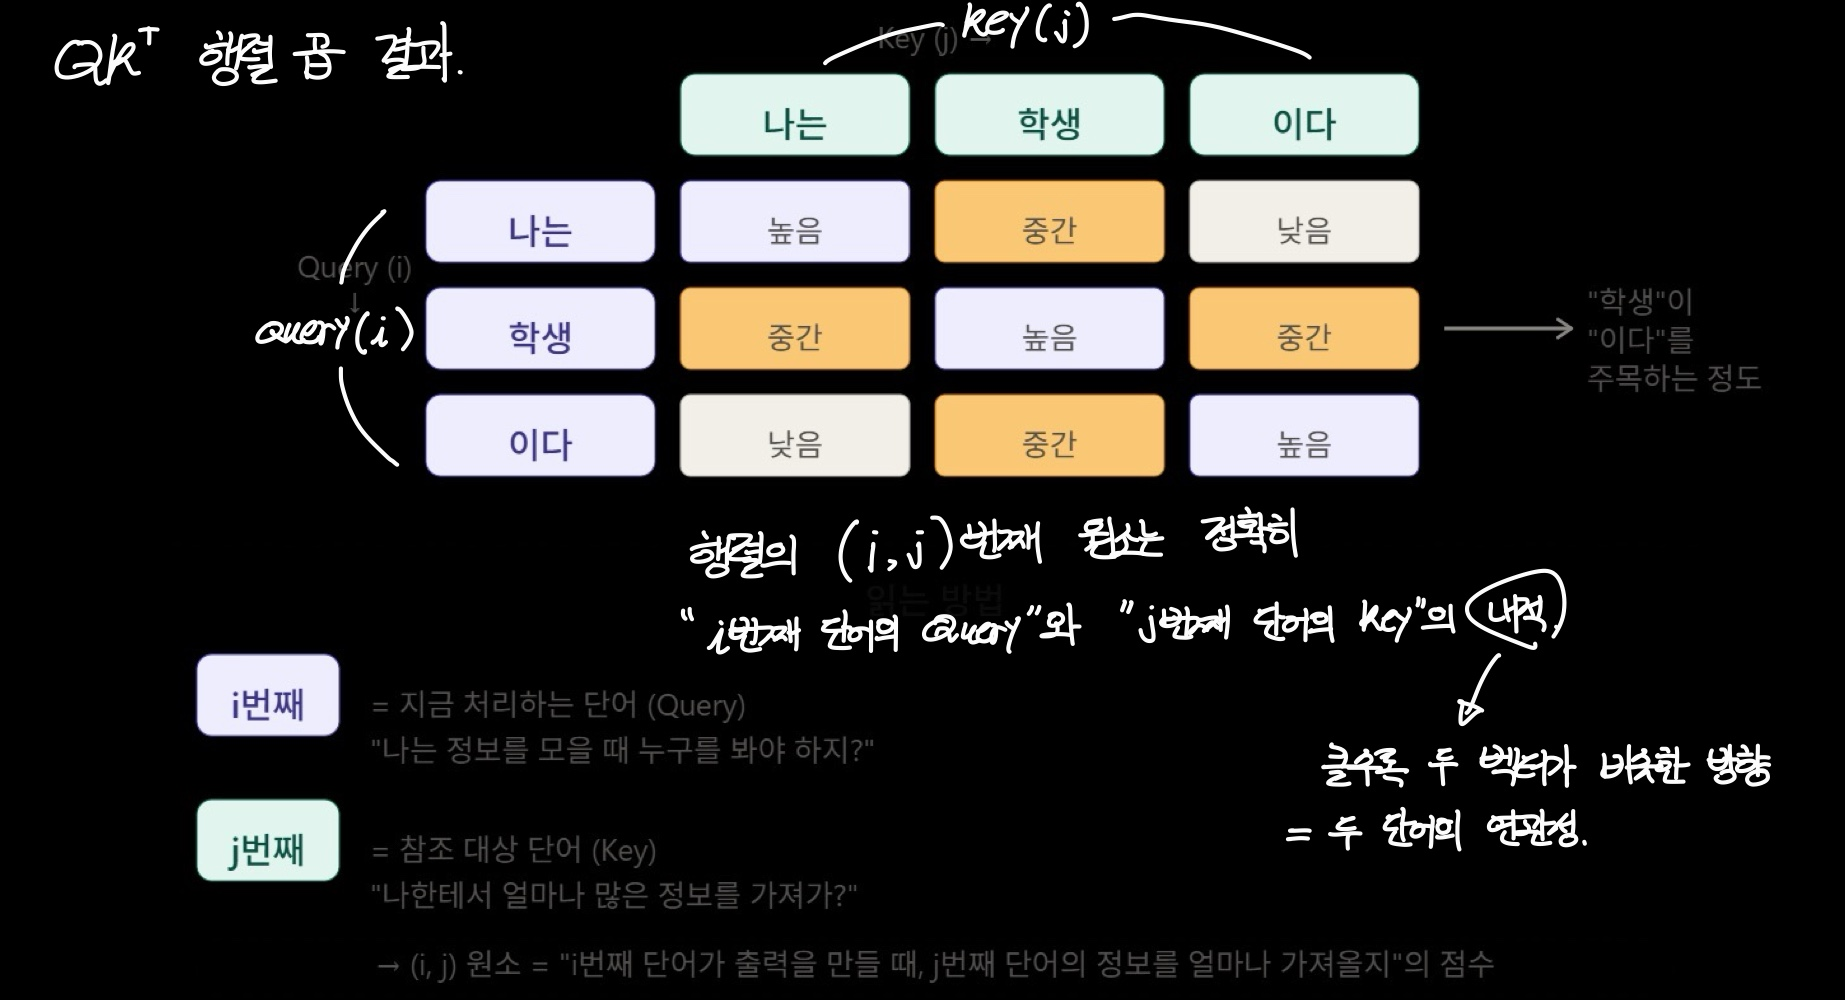

##### (2) $\sqrt{d_k}$로 나누기 - 왜 "스케일링"하는가
$d_k$ - $Q, K$ 벡터의 차원수 <br>
내적의 특징: 차원이 클수록 값이 커지는 경향 존재 (더하는 값이 많아지므로) <br>
-> 값이 커지면 다음 단계의 Softmax 사용 시 문제 발생 (Softmax는 지수함수를 사용하는데 입력값이 크면 $e^x$가 폭발적으로 커져 하나의 값에만 거의 100% 확률로 편향되어 기울기가 0이 됨) <br>
**"$\sqrt{d_k}$로 나눠 내적값의 분산을 일정하게 유지"해 문제 방지**

##### (3) Softmax = 유사도를 "주의 비중(가중치)로 변환" <br>
$\frac{QK^T}{\sqrt{d_k}}$의 각 행에 $Softmax$를 적용하면, 합이 1인 확률처럼 "주의를 얼마만큼 줄지"의 비중이 도출됨.

##### (4) Softmax 결과 $\times$ V - 가중합으로 정보 수집
마지막에 이 비중을 $Value$에 곱해서 더함 -> 관련 있는 단어의 $Value$는 많이 가져오고, 관련 없는 단어의 $Value$는 거의 무시.


#### 3. Attention이 RNN의 한계를 어떻게 해결했는가
- 정보 병목: 모든 단어의 Value를 그대로 보존해 필요 시마다 가중합으로 직접 조합
- 기울기 소실: 거리와 상관없이 내적 한 번으로 직접 연결
- 순차 처리 병렬화: $QK^T$는 모든 단어 쌍을 동시에(행렬곱 한 번으로) 계산해 병렬화


In [1]:
# NumPy로 구현

import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')[:3000]
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {c:i for i,c in enumerate(chars)}
data = [char_to_idx[c] for c in text]

def one_hot(idx):
    v = np.zeros((vocab_size,1)); v[idx]=1; return v

hidden_size = 16
np.random.seed(5)
Wx = np.random.randn(hidden_size, vocab_size) * 0.05
Wh = np.random.randn(hidden_size, hidden_size) * 0.05
bh = np.zeros((hidden_size,1))

# ── Day5와 동일하게 10글자를 읽되, 이번엔 "모든 시점"의 hidden state를 전부 보존 ──
enc_len = 10
enc_input = data[0:enc_len]
h = np.zeros((hidden_size,1))
H = []   # ★ Day5는 마지막 것만 남기고 버렸지만, 이번엔 전부 저장 (병목 해소의 시작)
for t in range(enc_len):
    h = np.tanh(Wx @ one_hot(enc_input[t]) + Wh @ h + bh)
    H.append(h.flatten())
H = np.array(H)               # (10, 16): 10개 시점 × 16차원

# ── Q, K, V로 각각 투영 ──
d_k = 8
np.random.seed(7)
WQ = np.random.randn(hidden_size, d_k) * 0.3
WK = np.random.randn(hidden_size, d_k) * 0.3
WV = np.random.randn(hidden_size, d_k) * 0.3
Q, K, V = H @ WQ, H @ WK, H @ WV     # 각 (10,8)

scores = Q @ K.T / np.sqrt(d_k)               # Step1~2: QKᵀ/√dₖ
def softmax_rows(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)
attn_weights = softmax_rows(scores)           # Step3: softmax (행 합=1)
output = attn_weights @ V                     # Step4: 가중합

print("attn_weights shape:", attn_weights.shape, "행 합:", round(attn_weights[0].sum(),4))
print("output shape:", output.shape)

attn_weights shape: (10, 10) 행 합: 1.0
output shape: (10, 8)


In [2]:
# Seq2Seq에 Attention을 적용한 예시(PyTorch)
import torch
import torch.nn as nn
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')[:3000]
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {c:i for i,c in enumerate(chars)}
data = [char_to_idx[c] for c in text]

hidden_size = 32
enc_len, dec_len = 10, 10
torch.manual_seed(3)

class Seq2SeqAttention(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.encoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.decoder_cell = nn.RNNCell(vocab_size + hidden_size, hidden_size)  # 입력+context 함께 받음
        self.WQ = nn.Linear(hidden_size, hidden_size, bias=False)
        self.WK = nn.Linear(hidden_size, hidden_size, bias=False)
        self.WV = nn.Linear(hidden_size, hidden_size, bias=False)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, enc_input, dec_input):
        # ── 인코더: 이번엔 "모든 시점의 출력"을 보존 (Day5는 마지막만 남기고 버렸음) ──
        enc_outputs, h = self.encoder(enc_input)   # enc_outputs: (batch,enc_len,hidden) ★병목 해소
        h = h.squeeze(0)

        K = self.WK(enc_outputs)
        V = self.WV(enc_outputs)

        logits_list, attn_all = [], []
        for t in range(dec_input.shape[1]):
            Q = self.WQ(h).unsqueeze(1)
            scores = torch.bmm(Q, K.transpose(1,2)) / (hidden_size**0.5)
            attn_weights = torch.softmax(scores, dim=-1)
            attn_all.append(attn_weights)
            context = torch.bmm(attn_weights, V).squeeze(1)   # ★ 매 디코딩 스텝마다 새로 계산되는 context

            dec_in_t = torch.cat([dec_input[:,t,:], context], dim=-1)
            h = self.decoder_cell(dec_in_t, h)
            logits_list.append(self.fc(h))
        return torch.stack(logits_list, dim=1), torch.cat(attn_all, dim=1)

model = Seq2SeqAttention(vocab_size, hidden_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def make_batch(batch_size):
    enc_in, dec_in, dec_tgt = [], [], []
    for _ in range(batch_size):
        p = np.random.randint(0, len(data)-enc_len-dec_len-1)
        enc_idx = data[p:p+enc_len]
        tgt_idx = data[p+enc_len:p+enc_len+dec_len]
        dec_in_idx = [char_to_idx['\n']] + tgt_idx[:-1]
        enc_in.append(enc_idx); dec_in.append(dec_in_idx); dec_tgt.append(tgt_idx)
    enc_in = torch.nn.functional.one_hot(torch.tensor(enc_in), vocab_size).float()
    dec_in = torch.nn.functional.one_hot(torch.tensor(dec_in), vocab_size).float()
    return enc_in, dec_in, torch.tensor(dec_tgt)

losses = []
for step in range(1500):
    enc_in, dec_in, dec_tgt = make_batch(32)
    logits, attn_w = model(enc_in, dec_in)
    loss = loss_fn(logits.reshape(-1, vocab_size), dec_tgt.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if step % 300 == 0:
        print(f"step {step:4d} | loss={np.mean(losses[-50:]):.3f}")

step    0 | loss=3.928
step  300 | loss=1.818
step  600 | loss=1.486
step  900 | loss=1.303
step 1200 | loss=1.174
